import numpy as np
import pandas as pd


In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load the dataset
# The dataset is in CSV format and is encoded in 'latin-1'. We will read it into a pandas DataFrame.

df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
# Display the first 5 rows of the DataFrame
df.sample(5)
#df.info()
# The dataset has 5 columns: 'v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', and 'Unnamed: 4'.
# The unnamed columns have 50, 12, and 6 non-null values respectively. We can drop these columns as they do not contain useful information for our analysis.
#v1 and v2 have 5572 non-null values, which means they are complete and can be used for our analysis.

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1956,ham,K...k:)why cant you come here and search job:),NaN,NaN,NaN
5046,ham,Hmmm.still we dont have opener?,NaN,NaN,NaN
3860,spam,Free Msg: Ringtone!From: http://tms. widelive....,NaN,NaN,NaN
531,ham,What Today-sunday..sunday is holiday..so no wo...,NaN,NaN,NaN
1221,ham,Prakesh is there know.,NaN,NaN,NaN


In [4]:
# Display the shape of the DataFrame (number of rows and columns)
df.shape

(5572, 5)

In [5]:
#we follow the below steps to build our model
#1. Data cleaning (removing unnecessary columns, handling missing values, duplicate value form dataset, etc.)

#2. EDA (Exploratory Data Analysis. This step involves visualizing the data to understand the distribution of spam and ham messages,
# as well as identifying any patterns or trends in the data.)

#3. Text Preprocessing (cleaning the text data by removing punctuation, converting to lowercase, removing stop words, etc.)

#4. Model Building (we will use a machine learning algorithm to build a model that can classify messages as spam or ham based on the text data.)

#5. Evaluation(we will evaluate the performance of our model using metrics such as accuracy, precision, recall, and F1-score 
# to determine how well it is able to classify messages as spam or ham.)

#6. Improvement(we will try to improve the performance of our model by tuning hyperparameters, using different algorithms, or adding more features to the model.)

#7. Website (we will create a simple web application using Flask or Django to allow users to input messages and receive predictions on whether the message is spam or ham.)

# Deployment

In [6]:
#above we see that the 3 unnamed columns have very less amount of data like, 50, 12, 6 non null values so we can drop those columns
#drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
#Now we have only 2 columns left, v1 and v2. We can rename these columns to something more meaningful.


df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5276,ham,Dunno leh cant remember mayb lor. So wat time ...,NaN,NaN,NaN
1324,ham,Can you call me plz. Your number shows out of ...,NaN,NaN,NaN
1166,ham,I am not having her number sir,NaN,NaN,NaN
3409,ham,Joy's father is John. Then John is the ____ of...,NaN,NaN,NaN
2080,ham,Where is it. Is there any opening for mca.,NaN,NaN,NaN


In [8]:
#rename the columns so that we can understand it better
#rename columns v1 to target and v2 to text
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
5498,ham,Why did I wake up on my own &gt;:(,NaN,NaN,NaN
1871,ham,Dont know supports ass and srt i thnk. I think...,NaN,NaN,NaN
2622,ham,Ok lor...,NaN,NaN,NaN
5519,ham,Can you pls send me that company name. In saib...,NaN,NaN,NaN
4078,ham,O i played smash bros &lt;#&gt; religiously.,NaN,NaN,NaN


In [9]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
#Ml model can only understand the numerical values but our 
#target column have categorical values ham and spam so we 
#need to convert those categorical values into numerical values ham =0 and spam =1
from sklearn.preprocessing import LabelEncoder
#create an instance of label encoder
#labecoder() is a class in the sklearn.preprocessing module that is used to convert categorical labels into numerical values.
#0 means ham and 1 means spam
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [11]:
#head is used to see the top 5 rows of the dataframe in pandas
#here we 
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
#check missing values in the dataset
df.isnull().sum()
#there are no missing values in the dataset

target           0
text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [13]:
#chekc duplicated values in the dataset
df.duplicated().sum()
#there are some duplicated values in the dataset so we have successfully removed the duplicated values

np.int64(403)

In [14]:
#remove duplicated values
#keep = first means we will keep the first occurrence of the duplicated value and drop the rest
df = df.drop_duplicates(keep='first')

In [15]:
#again check duplicated values in the dataset
df.duplicated().sum()

np.int64(0)

In [16]:
#after removing duplicated values we have total 5169 rows and 2 columns in the dataset
df.shape

(5169, 5)

2.EDA

In [17]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [18]:
#check how many ham and spam messages are there in the #dataset
#here 4516 me
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

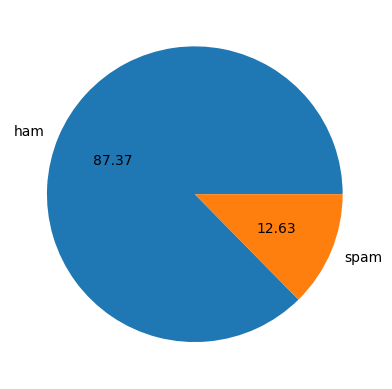

In [19]:
#visualization of ham and spam messages using pie chart
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()
#data is imbalanced because we have more ham messages than spam messages in the dataset

In [20]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
#we create 3 columns in the dataset for deeper analysis of the text data

#1. num_characters: number of characters in the text message

#2. num_words: number of words in the text message

#3. num_sentences: number of sentences in the text message
#to do this we need nltk library
#nltk is a natural language processing library in python which is used for text preprocessing and analysis
import nltk
#punkt is a pre-trained model in nltk which is used for tokenization of sentences and words
#we need to download the punkt model to load data into our model
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
#count number of characters in the text message in text column and store it in num_characters column
df['num_characters'] = df['text'].apply(len)

In [23]:
#top 5 rows of the dataframe
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61


In [24]:
#tokenize the text message into numbers and then count the number of words in the text message and store it in num_words column

#count number of words in the text message in text column and store it in num_words column

#nltk.word_tokenize is used to tokenize the text message into words and then we count the number of words in the text message

#lambda is an anonymous function in python which is used to create a function without a name

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [25]:
#num
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15


In [26]:
#what is te
#tokenize the text message into sentences and then count the number of sentences in the text message and store it in num_sentences column

#sent-tokenize is used to tokenize the text message into sentences and then we count the number of sentences in the text message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

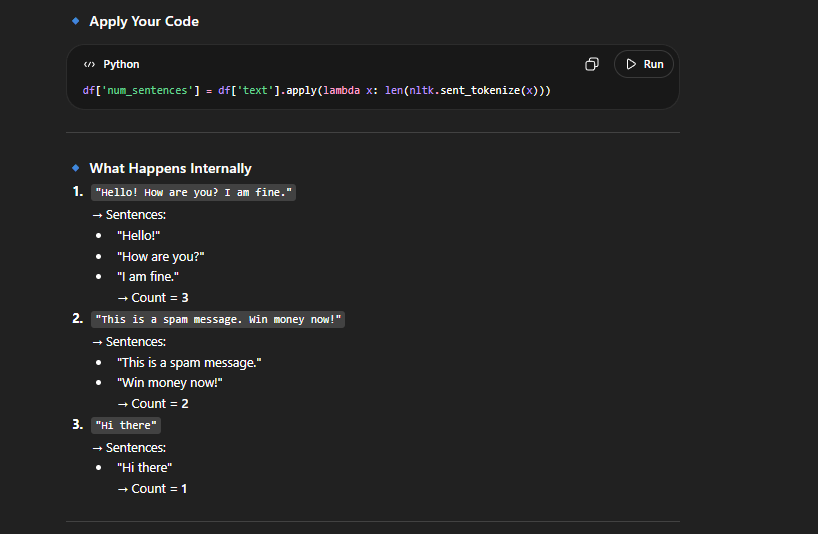

In [27]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1


In [28]:
#here describe is used to get the statistical summary of the numerical columns in the dataset
#here maximum number of characters in the text message is 910 and 
# minimum number of characters in the text message is 2 and 
# average number of characters in the text message is 71.48
#maximum number of words in the text message is 152 and
# minimum number of words in the text message is 1 and
# average number of words in the text message is 13.05
#maximum number of sentences in the text message is 10 and
# minimum number of sentences in the text message is 1 and
# average number of sentences in the text message is 1.75
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#here we will do the same analysis for ham messages only
#0 means ham messages and 1 means spam messages in the target column
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
#here we will do the same analysis for spam messages only
#0 means ham messages and 1 means spam messages in the target column
#minimum number of characters in the text message is 2 and
# average number of characters in the text message is 138.67 and
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [31]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='num_characters', ylabel='Count'>

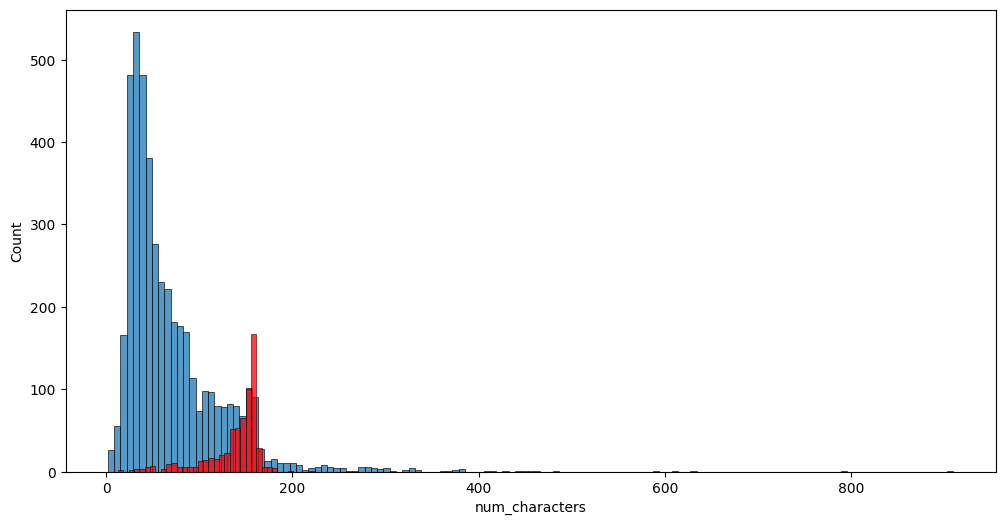

In [32]:
#we import seaborn library for data visualization
# we draw a histogram of num_characters column for ham and spam messages
#we see that most of the ham messages have less than 100 characters and most of the spam messages have more than 100 characters in the text message
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters']
,color='red')

<Axes: xlabel='num_words', ylabel='Count'>

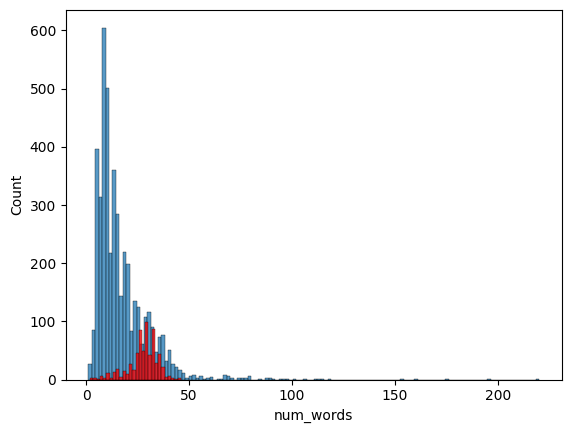

In [33]:
#we draw a histogram of num_words column for ham and spam messages
#We see that most of the ham messages have less than 20 words and most of the spam messages have more than 20 words in the text message
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words']
,color='red')

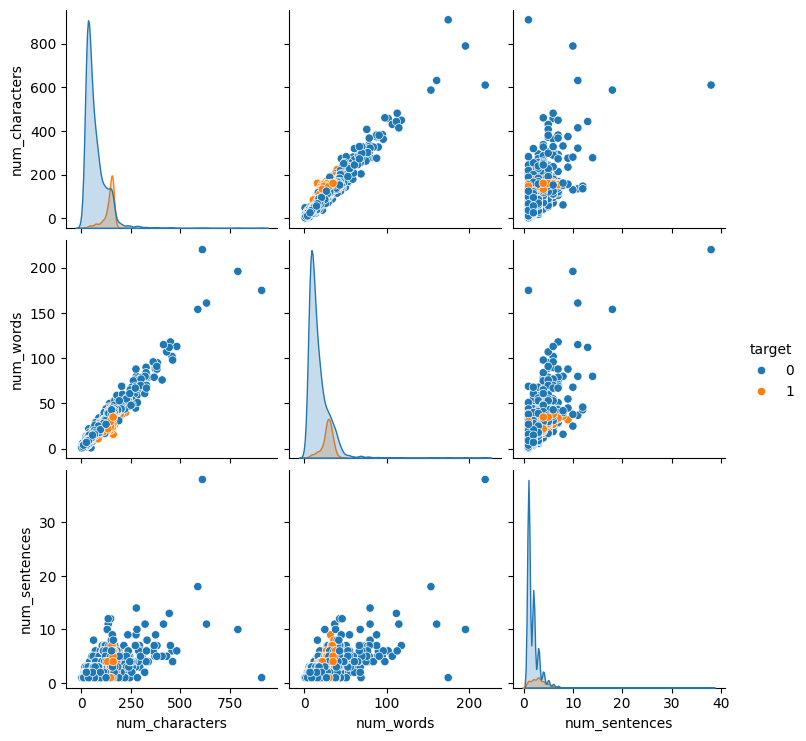

In [34]:
# we draw a pairplot to see the relationship between num_characters, num_words and num_sentences columns with the target column
#now we can we can see  the relationship between num_characters, num_words and num_sentences columns with the target column using pairplot
# below we see
sns.pairplot(df,hue='target')

<Axes: >

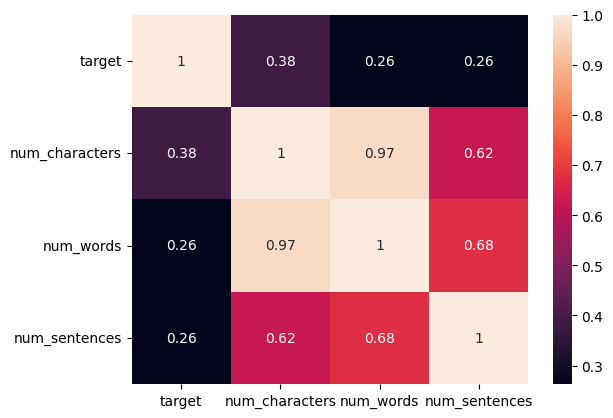

In [35]:
#heatmap is used to see the correlation between the numerical columns in the dataset
# corelation between target and num_characters is 0.38 which means there is a strong positive correlation between target and num_characters columns

#target vs num_characters (0.38): এখানে সম্পর্ক সবচেয়ে বেশি (০.৩৮)। এর মানে হলো, একটি মেসেজে কতগুলো অক্ষর আছে, তা দেখে স্প্যাম চেনার সম্ভাবনা সবচেয়ে বেশি।

#target vs num_words (0.26): এটিও গুরুত্বপূর্ণ, তবে ক্যারেক্টারের তুলনায় কিছুটা কম।

#target vs num_sentences (0.26): এটিও একই রকম প্রভাব ফেলে।
#এই চার্ট থেকে আমরা ৩টি সিদ্ধান্ত নিতে পারি:
#স্প্যাম মেসেজ সাধারণত বড় হয়: যেহেতু target এর সাথে num_characters এর একটি পজিটিভ সম্পর্ক আছে, তাই আমরা বলতে পারি মেসেজ যত বড় হবে, সেটি স্প্যাম হওয়ার সম্ভাবনা তত বাড়বে।

#কলাম বাছাই (Feature Selection): আপনার মডেল ট্রেইন করার সময় আপনি যদি শুধু একটি কলাম নিতে চান, তবে num_characters নেওয়া সবচেয়ে বুদ্ধিমানের কাজ হবে, কারণ এর কো-রিলেশন সবচেয়ে বেশি।

#অতিরিক্ত ডাটা: যেহেতু ক্যারেক্টার, শব্দ এবং বাক্য—এই তিনটিই একে অপরের সাথে খুব গভীরভাবে যুক্ত (০.৯৭), তাই তিনটিকে একসাথে মডেলে ব্যবহার করলে Multicollinearity সমস্যা হতে পারে। প্রোফেশনালরা সাধারণত এখান থেকে শুধু সেরা একটিকে বেছে নেন।

#so we choose num_characters column for our model building because it has the highest correlation with the target column
sns.heatmap(df.corr(numeric_only=True), annot=True)

3.Data preprocessing or Text preprocessing 

 

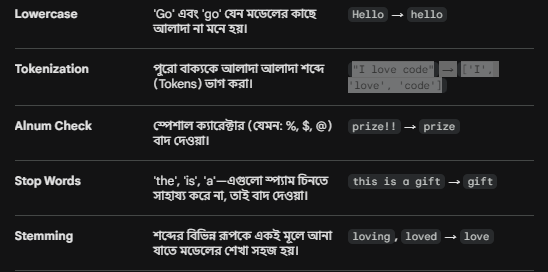


#lowercase
#Tokenization
#Removing special characters
#Removing stop words and punctuation     
#Stemming

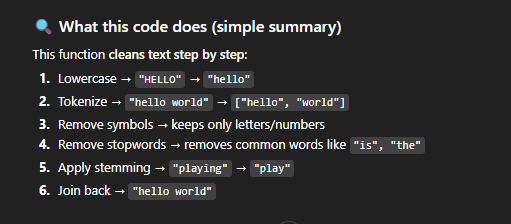

In [36]:
# import built-in string module (used for punctuation like .,!? etc.)
import string

# import stopwords list from nltk (common words like "is", "the", "and")
from nltk.corpus import stopwords

# import PorterStemmer (used to convert words into root form)
from nltk.stem.porter import PorterStemmer

# create an object of PorterStemmer
ps = PorterStemmer()

# example: stemming a word ("loving" → "love")
ps.stem('loving')


# load all English stopwords and store in a set (faster searching)
stop_words = set(stopwords.words('english'))


# define a function to clean and transform text
def transform_text(text):

    # convert all text to lowercase (Example: "Hello" → "hello")
    text = text.lower()

    # convert sentence into list of words (tokenization)
    text = nltk.word_tokenize(text)


    # create an empty list to store clean words
    y = []

    # loop through each word
    #remove punctuation
    for i in text:
        # keep only alphanumeric words (remove symbols like @,#,$ etc.)
        if i.isalnum():
            y.append(i) 


    # copy cleaned words back to text
    text = y[:]

    # clear y list to reuse it
    y.clear()


    # remove stopwords and punctuation
    for i in text:
        # keep word only if:
        # 1. not a stopword
        # 2. not a punctuation mark
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    

    # copy again for next step (stemming)
    text = y[:]

    # clear y list again
    y.clear()


    # apply stemming (convert word to root form)
    for i in text:
        # Example: "playing" → "play"
        y.append(ps.stem(i))    


    # join all words into a single string and return
    return " ".join(y)

In [37]:
#all stop words in the english language
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [38]:
#punctuation marks in the english language
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [39]:
#stemming is the process of reducing a word to its root word
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')
ps.stem('liked')

'like'

In [40]:
# apply the transform_text function to the text column in the dataset and store it in a new column called transformed_text
df['transformed_text'] = df['text'].apply(transform_text)

In [41]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [42]:
# ১. Unnamed কলামগুলো মুছে ফেলা
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

# ২. চেক করে দেখুন কলামগুলো গেছে কি না
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [43]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
#what is wrdcloud?
#wordcloud হলো একটি ভিজ্যুয়ালাইজেশন টুল যা টেক্সট ডেটার মধ্যে শব্দগুলির ফ্রিকোয়েন্সি  গ্রাফিক্যালি প্রদর্শন করে। এটি সাধারণত একটি ক্লাউডের মতো দেখতে হয় যেখানে শব্দগুলি তাদের ফ্রিকোয়েন্সি অনুযায়ী বিভিন্ন আকারে এবং রঙে প্রদর্শিত হয়। বেশি ব্যবহৃত শব্দগুলি বড় আকারে এবং কম ব্যবহৃত শব্দগুলি ছোট আকারে প্রদর্শিত হয়। এটি টেক্সট ডেটার মধ্যে গুরুত্বপূর্ণ শব্দগুলি দ্রুত চিহ্নিত করতে সাহায্য করে এবং সাধারণত স্প্যাম ডিটেকশন, সোশ্যাল মিডিয়া এনালাইসিস, এবং অন্যান্য ন্যাচারাল ল্যাঙ্গুয়েজ প্রসেসিং (NLP) প্রজেক্টে ব্যবহৃত হয়।
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')


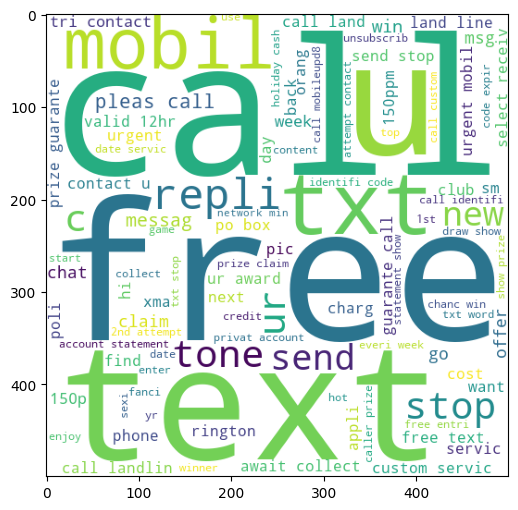

In [45]:
#what we do here?
#generate a word cloud for ham messages and spam messages separately to see the most common words in ham and spam messages
#and the Big words are the most common words in ham and spam messages
#here most common words in spam messages are call, free, mobile, text, claim, prize, etc. and most common words in ham messages are ok, love, good, etc.
spam_wc= wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" )"))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

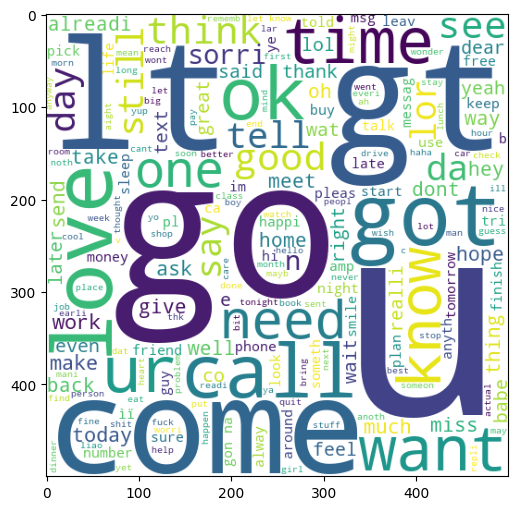

In [46]:
#generate a word cloud for ham messages and spam messages separately to see the most common words in ham and spam messages
#and the Big words are the most common words in ham and spam messages
#here most common words in spam messages are call, come,love ,time ,go, got, want
ham_wc= wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [47]:
df.head()


,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [48]:
# see top 30 words in ham messages and spam messages using countplot
spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [49]:
len(spam_corpus)

9939

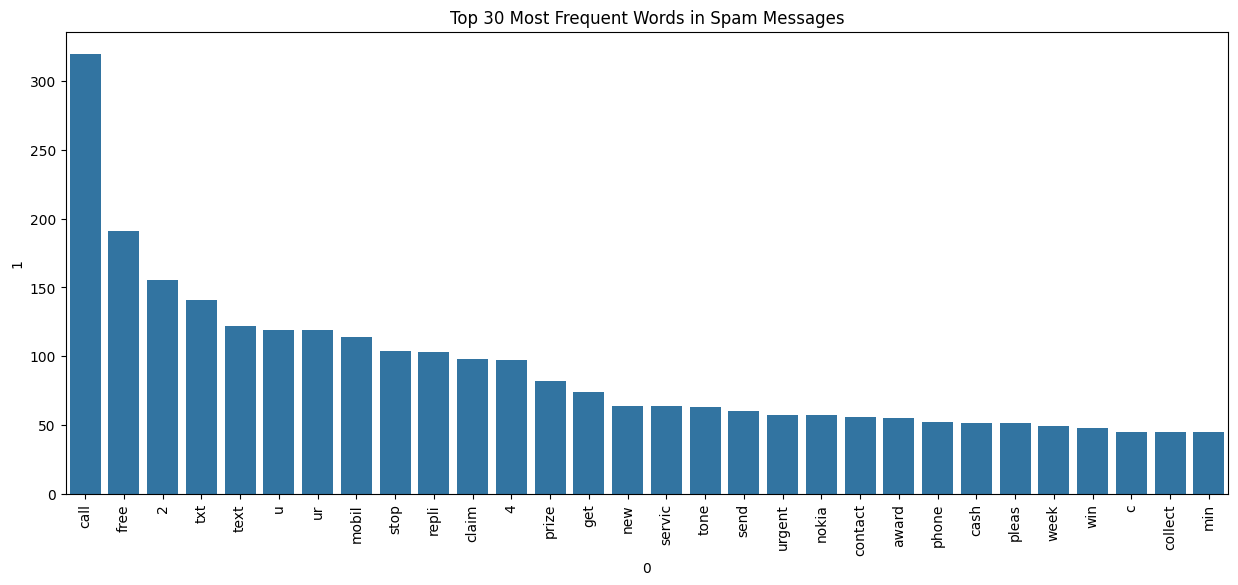

In [50]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ১. স্প্যাম কর্পাস থেকে সবচেয়ে বেশি আসা ৩০টি শব্দ এবং তাদের সংখ্যা দিয়ে একটি ডাটাফ্রেম তৈরি করা
# Counter(...).most_common(30) সরাসরি একটি লিস্ট দেয়, যা পাণ্ডাস সহজেই পড়তে পারে
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

# ২. বারপ্লট তৈরি করা
plt.figure(figsize=(15,6))
sns.barplot(x=most_common_df[0], y=most_common_df[1])

# ৩. নামগুলো যাতে একটার ওপর আরেকটা না পড়ে, তাই ভার্টিক্যাল (Vertical) করে দেওয়া
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Frequent Words in Spam Messages')
plt.show()

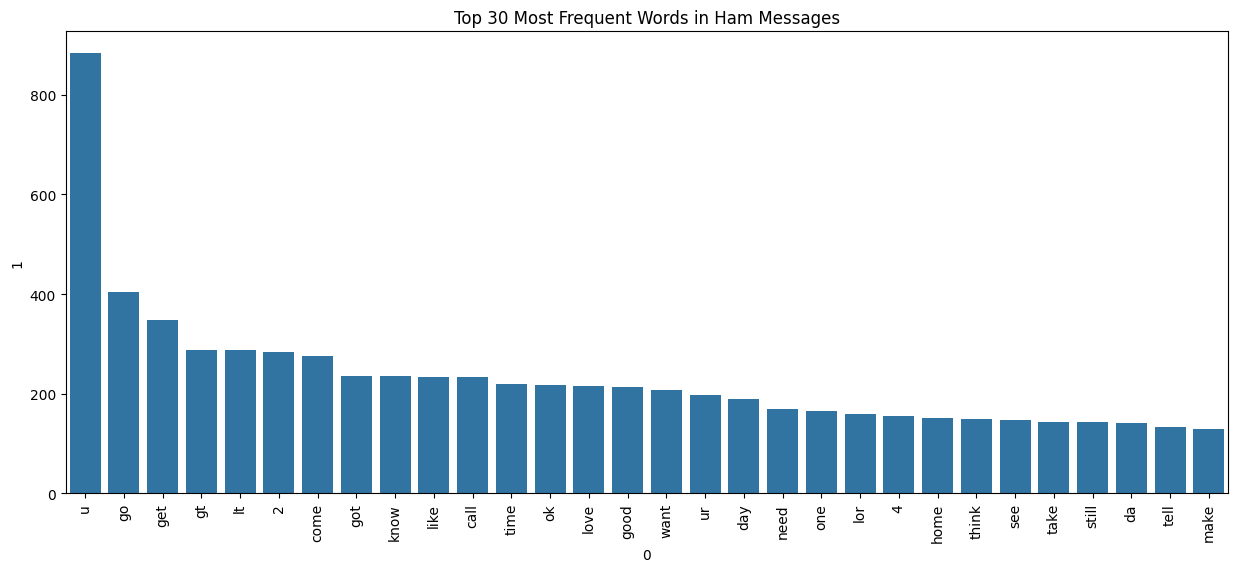

In [51]:
#Top 30 most common words in ham messages
# see top 30 words in ham messages and spam messages using countplot
# ১. হ্যাম মেসেজের সব শব্দগুলো একটি লিস্টে (ham_corpus) জমা করা
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

# ২. সবচেয়ে বেশি আসা ৩০টি শব্দ নিয়ে ডেটাফ্রেম তৈরি করা
from collections import Counter
most_common_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

# ৩. বার-প্লট তৈরি করা
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.barplot(x=most_common_ham[0], y=most_common_ham[1])

# ৪. এক্স-অক্ষের লেখাগুলো ভার্টিক্যাল করে দেওয়া
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Frequent Words in Ham Messages')
plt.show()

In [52]:
len(ham_corpus)

35404

4.Model Building

In [53]:
#1.Text → Numbers (Feature Engineering)
#Import tools to convert text into numbers (ML models only understand numbers)

#Ml model can only understand the numerical values but we have text values in the text column so we need to convert those text values into numerical values
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
#Converts text into word counts (not used later)
#প্রতিটি word কতবার এসেছে তা count করে
cv = CountVectorizer()


In [54]:
#What: We use TF-IDF (Term Frequency-Inverse Document Frequency) to convert text into a matrix of numbers. We limited it to the top 3,000 most important words.

#Why: Machine Learning models can't "read" English; they only understand math. TF-IDF is great because it gives more weight to unique words and less weight to common words like "the" or "is."

#Output: A table (matrix) with 5,169 rows (messages) and 3,000 columns (word scores).

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [55]:
X.shape

(5169, 3000)

In [56]:
y = df['target'].values

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
#What: We split the data: 80% for training the model and 20% for testing its performance.

#Why: To ensure the model isn't just "memorizing" the answers. We test it on data it has never seen before.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [59]:
#here we will use Naive Bayes algorithm to build our model because it is a simple and effective algorithm for text classification problems like spam detection

#There are 3 types of Naive Bayes algorithms: GaussianNB, MultinomialNB, and BernoulliNB. We will use MultinomialNB algorithm to build our model because it is a good algorithm for text classification problems like spam detection
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB


#Below we Import evaluation metrics:

#Accuracy → overall correctness 
#Precision → spam prediction quality
#Confusion Matrix → detailed result

from sklearn.metrics import accuracy_score,confusion_matrix,precision_score ,f1_score

In [60]:
# here we  create our models 
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

Evaluation

In [61]:
#we will train our model using GaussianNB algorithm and evaluate its performance using accuracy_score, confusion_matrix, and precision_score metrics
#X_train = input features (text converted to numbers)
#y_train = actual labels (0 = ham, 1 = spam)
#X_test = test features (text converted to numbers)
#y_test = test labels (0 = ham, 1 = spam)
# Model predicts labels for unseen test data
#y_pred1 = predicted labels for test data using GaussianNB model
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(f1_score(y_test, y_pred1))   # 👉 F1-score

#print(accuracy_score(y_test, y_pred1))
#output 0.874
#meaning of accuracy score 0.874 is that our model is able to correctly classify 87.4% of the messages as either ham or spam based on the test data it has never seen before.
#87.4% predictions are correct

#print(confusion_matrix(y_test, y_pred1))
#Confusion Matrix is a table that is used to evaluate the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. In our case, it will show how many messages were correctly classified as ham (true negatives), how many were correctly classified as spam (true positives), how many were incorrectly classified as ham (false negatives), and how many were incorrectly classified as spam (false positives).

#[[790 106] meaning 790 messages were correctly classified as ham and 106 messages were incorrectly classified as ham

# [ 24 114]] meaning 24 messages were incorrectly classified as spam and 114 messages were correctly classified as spam
#true negative = 790
#true positive = 114
#false negative = 24(spam  but model ditect not spam)
#false positive = 106 (ham but model ditect as spam)

#recall = 114 /(114+106) = 0.51818
#F1 score =
#print(precision_score(y_test, y_pred1))\
#Precision Score is a metric that is used to evaluate the performance of a classification model. It is the ratio of true positives to the sum of true positives and false positives. In our case, it will show how many messages were correctly classified as spam (true positives) out of all the messages that were classified as spam (true positives + false positives). A precision score of 0.518 means that out of all the messages that were classified as spam, 51.8% were actually spam and the rest were ham.

#Only 51.8% correct
#Very poor performance for spam detection

#precision 

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182
0.6368715083798883


In [ ]:
#we will train our model using GaussianNB algorithm and evaluate its performance using accuracy_score, confusion_matrix, and precision_score metrics
#X_train = input features (text converted to numbers)
#y_train = actual labels (0 = ham, 1 = spam)
#X_test = test features (text converted to numbers)
#y_test = test labels (0 = ham, 1 = spam)
# Model predicts labels for unseen test data
#y_pred1 = predicted labels for test data using GaussianNB model
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(f1_score(y_test, y_pred1))   # 👉 F1-score

#print(accuracy_score(y_test, y_pred1))
#output 0.874
#meaning of accuracy score 0.874 is that our model is able to correctly classify 87.4% of the messages as either ham or spam based on the test data it has never seen before.
#87.4% predictions are correct

#print(confusion_matrix(y_test, y_pred1))
#Confusion Matrix is a table that is used to evaluate the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. In our case, it will show how many messages were correctly classified as ham (true negatives), how many were correctly classified as spam (true positives), how many were incorrectly classified as ham (false negatives), and how many were incorrectly classified as spam (false positives).

#[[790 106] meaning 790 messages were correctly classified as ham and 106 messages were incorrectly classified as ham

# [ 24 114]] meaning 24 messages were incorrectly classified as spam and 114 messages were correctly classified as spam
#true negative = 790
#true positive = 114
#false negative = 24(spam  but model ditect not spam)
#false positive = 106 (ham but model ditect as spam)

#recall = 114 /(114+106) = 0.51818
#F1 score =
#print(precision_score(y_test, y_pred1))\
#Precision Score is a metric that is used to evaluate the performance of a classification model. It is the ratio of true positives to the sum of true positives and false positives. In our case, it will show how many messages were correctly classified as spam (true positives) out of all the messages that were classified as spam (true positives + false positives). A precision score of 0.518 means that out of all the messages that were classified as spam, 51.8% were actually spam and the rest were ham.

#Only 51.8% correct
#Very poor performance for spam detection

#precision 

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182
0.6368715083798883


In [62]:
#mnb.fit(X_train, y_train) means we are training our model using MultinomialNB algorithm and evaluating its performance using accuracy_score, confusion_matrix, and precision_score metrics
#y_pred2 = mnb.predict(X_test) predict test data using MultinomialNB
#X_train = input features (text converted to numbers)
#y_train = actual labels (0 = ham, 1 = spam)
#X_test = test features (text converted to numbers)
#y_test = test labels (0 = ham, 1 = spam)

#print(confusion_matrix(y_test,y_pred2)
#Confusion Matrix is a table that is used to evaluate the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. In our case, it will show how many messages were correctly classified as ham (true negatives), how many were correctly classified as spam (true positives), how many were incorrectly classified as ham (false negatives), and how many were incorrectly classified as spam (false positives).

mnb.fit(X_train, y_train)

y_pred1 = mnb.predict(X_test)

print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))
print(f1_score(y_test, y_pred1))   # 👉 F1-score

##print(accuracy_score(y_test, y_pred1))
#output 0.9709
#meaning of accuracy score 0.9709 is that our model is able to correctly classify 97.09% of the messages as either ham or spam based on the test data it has never seen before.
#97.09% predictions are correct

#print(confusion_matrix(y_test,y_pred2))
#output [[896   0] [ 30 108]] meaning 896 messages were correctly classified as ham and 0 messages were incorrectly classified as ham and 30 messages were incorrectly classified as spam and 108 messages were correctly classified as spam
#True negative = 896
#True positive = 108
#False negative = 30
#False positive = 0

#Precision = (TP/ (TP + FP)) = (108/(108 + 0)) = 1.0 
#Recall value = (TP/ (TP + FN)) = (108 / (108 + 30)) = 0.78260
#F1_Score = (2 * precision * recall )(precision + recall) =(2 * 1.0 * 0.7826)/(1.0+ 0.7826) = 87.78

#print(precision_score(y_test, y_pred2))
#output :1.0 meaning of precision score 1.0 is that out of all the messages that were classified as spam, 100% were actually spam and the rest were ham. This indicates that the MultinomialNB model has a perfect precision for spam detection, meaning it is very good at correctly identifying spam messages while minimizing false positives (incorrectly classifying ham as spam).


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0
0.8780487804878049


In [63]:
#accuracy score is 0.9835 which means our model is able to correctly classify 98.35% of the messages as either ham or spam based on the test data it has never seen before.
#correct predictions are 98.35%

#bnb.fit(X_train, y_train) means we are training our model using BernoulliNB algorithm and evaluating its performance using accuracy_score, confusion_matrix, and precision_score metrics
#y_pred3 = bnb.predict(X_test) predict test data using BernoulliNB model

#X_train = input features (text converted to numbers)
#y_train = actual labels (0 = ham, 1 = spam)
#X_test = test features (text converted to numbers)
#y_test = test labels (0 = ham, 1 = spam)
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
print(f1_score(y_test, y_pred3))   # 👉 F1-score
# print(confusion_matrix(y_test, y_pred3)) confusion matrix for BernoulliNB model
# [[895   1] meaning 895 messages were correctly classified as ham and 1
#[16, 122]] meaning 16 messages were incorrectly classified as spam and 122 messages were correctly classified as spam
#True negative = 895
#True positive = 122
#False negative = 16
#False positive = 1

#Precision = (TP/ (TP + FP)) = (122/(122 + 1)) = 0.99186
#Recall value = (TP/ (TP + FN)) = (122 / (122 + 16)) = 0.8840
#F1_Score = (2 * precision * recall )(precision + recall) =(2 * 0.991 * 0.884)/(0.991+ 0.884) = 87.78

#print(precision_score(y_test, y_pred3))  precision score for BernoulliNB model is 0.991 which means that out of all the messages that were classified as spam, 99.1% were actually spam and the rest were ham. This indicates that the BernoulliNB model has a very high precision for spam detection, meaning it is very good at correctly identifying spam messages while minimizing false positives (incorrectly classifying ham as spam).

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187
0.9348659003831418


tfidf-->MNB

In [64]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
# importing various machine learning algorithms for compareing the performance of our model with other algorithms and find the best algorithm/model for our spam detection problem

#SVC menas Support Vector Classifier which is a supervised machine learning algorithm used for classification tasks. It works by finding the optimal hyperplane that best separates the classes in the feature space.

#LogisticRegression is a statistical model that is used for binary classification problems. It estimates the probability of a binary response based on one or more predictor variables.

#MultinomialNB is a variant of the Naive Bayes algorithm that is used for classification tasks with discrete features, such as word counts in text classification.

#DecisionTreeClassifier is a supervised machine learning algorithm that is used for classification and regression tasks. It works by creating a tree-like model of decisions based on the features of the data.

#KNeighborsClassifier is a supervised machine learning algorithm that is used for classification and regression tasks. It works by finding the k nearest neighbors of a data point and making predictions based on the majority class among those neighbors.

#RandomForestClassifier is an ensemble learning method that is used for classification and regression tasks. It works by creating multiple decision trees and combining their predictions to improve accuracy and reduce overfitting.

#AdaBoostClassifier is an ensemble learning method that is used for classification tasks. It works by combining multiple weak classifiers to create a strong classifier that can make accurate predictions.

#BaggingClassifier is an ensemble learning method that is used for classification and regression tasks. It works by creating multiple subsets of the training data and training a separate model on each subset, then combining their predictions to improve accuracy.

#ExtraTreesClassifier is an ensemble learning method that is used for classification and regression tasks. It works by creating multiple decision trees and randomly selecting features for each split, which helps to reduce overfitting and improve accuracy.

#GradientBoostingClassifier is an ensemble learning method that is used for classification and regression tasks. It works by building a series of weak classifiers, where each subsequent classifier focuses on the errors made by the previous ones, ultimately creating a strong classifier.

#XGBClassifier is an implementation of the Gradient Boosting algorithm that is optimized for speed and performance. It is widely used in machine learning competitions and real-world applications for classification and regression tasks.

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [66]:
#here  we create instances of various machine learning algorithms with specific hyperparameters to compare their performance on our spam detection problem. 

#what is gamma in SVC?
# Gamma is a parameter in the SVM algorithm that controls the influence of each training example. A low gamma value means that the influence of a single training example reaches further, while a high gamma value means that the influence of a single training example reaches less.

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [67]:
#here store all the models in a dictionary for easy access and comparison of their performance later on
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [68]:
#here we define a function to train the model and evaluate its performance using accuracy_score and precision_score metrics

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [69]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [70]:

accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9323017408123792
Precision -  0.8333333333333334
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


c:\Users\Sadman\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sadman\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [71]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.932302,0.833333


In [72]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [73]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.932302


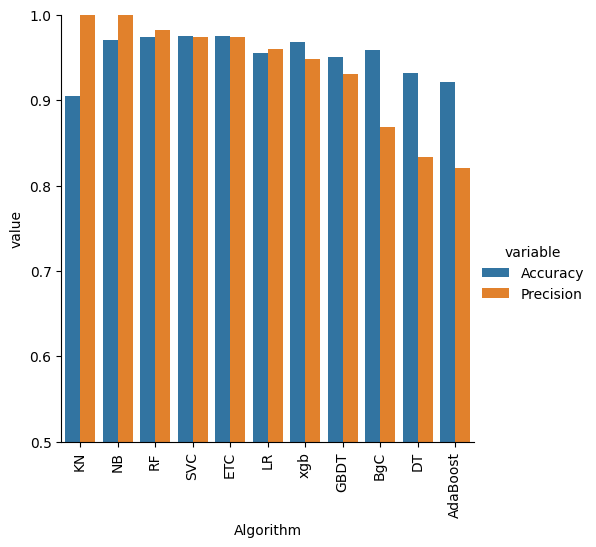

In [74]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

Model Improving

# model improve
# 1. Change the max_features parameter of TfIdf

In [75]:
# =========================================================
# PROJECT EXPLANATION (IMPORTANT - READ FIRST)
# =========================================================
# In this part, we are improving our SMS Spam Detection model.
#
#  What we do:
# - We test advanced models (Voting & Stacking)
# - Compare their performance using:
#     Accuracy, Precision, F1-score, Confusion Matrix
#
#  How we do:
# - Use 3 base models:
#     1. Bernoulli Naive Bayes (BNB)
#     2. Support Vector Machine (SVM)
#     3. Extra Trees Classifier (ETC)
#
# - Then combine them using:
#     ✔ Voting Classifier (Soft Voting)
#     ✔ Stacking Classifier (Meta Model)
#
#  Goal:
# - Improve spam detection performance
#
# Final Model Decision:
# - Even if ensemble models give slightly better accuracy,
#   we choose BernoulliNB because:
#     ✔ High precision (less false spam)
#     ✔ Simple and fast
#     ✔ Good for real-time systems
#
# =========================================================


# Import necessary libraries
import pandas as pd                      # for data handling
import pickle                           # for saving model
from sklearn.naive_bayes import BernoulliNB, MultinomialNB  # Naive Bayes models
from sklearn.svm import SVC             # Support Vector Machine
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score


# =========================================================
# 1️⃣ Initialize Base Models
# =========================================================

# Bernoulli Naive Bayes (Best for binary features)
bnb = BernoulliNB()

# Support Vector Machine
# kernel='sigmoid' → type of decision boundary
# probability=True → needed for soft voting
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)

# Extra Trees Classifier (ensemble tree-based model)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)


# =========================================================
# 2️⃣ Voting Classifier (Ensemble Method)
# =========================================================

# Combine multiple models
# 'soft' voting means → use probability to decide final output
voting = VotingClassifier(
    estimators=[('svm', svc), ('bnb', bnb), ('et', etc)],
    voting='soft'
)

# Train model
voting.fit(X_train, y_train)

# Predict on test data
y_pred_vote = voting.predict(X_test)


# =========================================================
# 📊 Voting Results
# =========================================================

print("--- Voting Classifier Results ---")

# Accuracy → overall correct prediction
print("Accuracy:", accuracy_score(y_test, y_pred_vote))

# Precision → how many predicted spam are actually spam
print("Precision:", precision_score(y_test, y_pred_vote))

# F1-score → balance between precision and recall
print("F1-score:", f1_score(y_test, y_pred_vote))

# Confusion Matrix:
# [[TN FP]
#  [FN TP]]
print(confusion_matrix(y_test, y_pred_vote))


# =========================================================
# 3️⃣ Stacking Classifier
# =========================================================

# Base models
estimators = [('svm', svc), ('bnb', bnb), ('et', etc)]

# Final model (meta learner)
# RandomForest learns how to combine predictions
final_estimator = RandomForestClassifier()

# Create stacking model
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator
)

# Train stacking model
stack.fit(X_train, y_train)

# Predict
y_pred_stack = stack.predict(X_test)


# =========================================================
# 📊 Stacking Results
# =========================================================

print("\n--- Stacking Classifier Results ---")

print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("F1-score:", f1_score(y_test, y_pred_stack))


# =========================================================
# 4️⃣ Final Model Selection (Deployment)
# =========================================================

# 👉 Even though Voting/Stacking are strong,
# we choose BernoulliNB for final deployment

best_model = BernoulliNB()

# Train final model
best_model.fit(X_train, y_train)


# =========================================================
# 💾 Save Model (VERY IMPORTANT)
# =========================================================

# Save trained model
pickle.dump(best_model, open('model.pkl', 'wb'))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))


# =========================================================
# 🔥 FINAL SUMMARY (VERY IMPORTANT FOR EXAM/VIVA)
# =========================================================
# Voting Classifier:
# ✔ High precision
# ✔ Good performance
#
# Stacking Classifier:
# ✔ Highest accuracy & F1-score
# ❌ Lower precision (risk of false spam)
#
# BernoulliNB:
# ✔ Simple
# ✔ Fast
# ✔ High precision
# ✔ Best for real-time system
#
# 👉 FINAL CHOICE = BernoulliNB
#
# Because:
# ✔ Safe (less false positive)
# ✔ Efficient
# ✔ Works well with text data
#
# =========================================================

--- Voting Classifier Results ---
Accuracy: 0.9845261121856866
Precision: 1.0
F1-score: 0.9384615384615385
[[896   0]
 [ 16 122]]

--- Stacking Classifier Results ---
Accuracy: 0.9864603481624759
Precision: 0.984375
F1-score: 0.9473684210526315
